# Game Theory Applied to Trading

Apply Nash equilibrium analysis, auction theory, and repeated-game reasoning to multi-agent trading environments, with direct application to IMC Prosperity 4.

**Theory references:** [Nash Equilibrium](../theory/05_game_theory/nash_equilibrium.md) | [Auction Theory](../theory/05_game_theory/auction_theory.md) | [Repeated Games](../theory/05_game_theory/repeated_games.md)

In [1]:
from __future__ import annotations

import os

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

mpl.rcParams.update({
    'font.family': 'serif', 'font.size': 11, 'axes.labelsize': 11,
    'axes.titlesize': 12, 'axes.titleweight': 'normal',
    'legend.fontsize': 10, 'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linewidth': 0.5,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})
COLORS = ['#534AB7', '#0F6E56', '#D85A30', '#185FA5', '#993556', '#3B6D11', '#BA7517']


def save_fig(fig: plt.Figure, topic: str, name: str) -> None:
    """Save figure to plots/<topic>/ as both PDF and PNG."""
    folder = os.path.join('..', 'plots', topic)
    os.makedirs(folder, exist_ok=True)
    for ext in ('pdf', 'png'):
        fig.savefig(os.path.join(folder, f'{name}.{ext}'))
    print(f'Saved \u2192 plots/{topic}/{name}.[pdf|png]')


## Section 1 — Nash Equilibria

### Normal-Form Games

A **normal-form (strategic-form) game** consists of:
- A finite set of players $\{1, 2, \ldots, N\}$.
- For each player $i$, a strategy set $S_i$.
- For each player $i$, a payoff function $u_i : S_1 \times S_2 \times \cdots \times S_N \to \mathbb{R}$.

In a two-player game with $m$ and $n$ strategies respectively, payoffs are represented by matrices $A \in \mathbb{R}^{m \times n}$ (row player) and $B \in \mathbb{R}^{m \times n}$ (column player).

### Nash Equilibrium

A strategy profile $(s_1^*, s_2^*, \ldots, s_N^*)$ is a **Nash equilibrium** if no player can improve their payoff by unilaterally deviating:

$$u_i(s_i^*, s_{-i}^*) \geq u_i(s_i, s_{-i}^*) \quad \forall\, s_i \in S_i, \;\forall\, i$$

**Pure-strategy NE:** each player picks a single deterministic action.

**Mixed-strategy NE:** players randomise over actions according to probability distributions $\sigma_i \in \Delta(S_i)$. Nash's theorem (1950) guarantees that every finite game has at least one mixed-strategy equilibrium.

### Finding Pure-Strategy NE

For a two-player game with payoff matrices $A$ and $B$:
1. For each column $j$, find the row(s) maximising $A_{ij}$ — these are Player A's best responses.
2. For each row $i$, find the column(s) maximising $B_{ij}$ — these are Player B's best responses.
3. A cell $(i, j)$ is a pure NE if and only if $i$ is a best response to $j$ **and** $j$ is a best response to $i$.

In [2]:
def find_pure_nash(payoff_A: np.ndarray, payoff_B: np.ndarray) -> list[tuple[int, int]]:
    """Find all pure-strategy Nash equilibria in a two-player normal-form game.

    Parameters
    ----------
    payoff_A : np.ndarray
        (m, n) array of Player A's (row player's) payoffs.
    payoff_B : np.ndarray
        (m, n) array of Player B's (column player's) payoffs.

    Returns
    -------
    list[tuple[int, int]]
        (row, col) index pairs that are pure-strategy Nash equilibria.
    """
    m, n = payoff_A.shape
    equilibria: list[tuple[int, int]] = []
    for i in range(m):
        for j in range(n):
            if payoff_A[i, j] >= np.max(payoff_A[:, j]):
                if payoff_B[i, j] >= np.max(payoff_B[i, :]):
                    equilibria.append((i, j))
    return equilibria

In [3]:
games = [
    {
        'title': "Prisoner's Dilemma",
        'strategies': ['Cooperate', 'Defect'],
        'A': np.array([[3, 0], [5, 1]]),
        'B': np.array([[3, 5], [0, 1]]),
    },
    {
        'title': 'Stag Hunt (Coordination)',
        'strategies': ['Stag', 'Hare'],
        'A': np.array([[4, 0], [3, 2]]),
        'B': np.array([[4, 3], [0, 2]]),
    },
    {
        'title': 'Market Entry',
        'strategies': ['Enter', 'Stay Out'],
        'A': np.array([[-1, 2], [0, 0]]),
        'B': np.array([[-1, 0], [2, 0]]),
    },
]

for game in games:
    ne = find_pure_nash(game['A'], game['B'])
    strats = game['strategies']
    print(f"=== {game['title']} ===")
    print("  Payoff matrix  (row = Player A, col = Player B):")
    header = ''.ljust(14) + ''.join(s.center(14) for s in strats)
    print(f"  {header}")
    m, n = game['A'].shape
    for i in range(m):
        row_str = strats[i].ljust(14)
        for j in range(n):
            cell = f"({game['A'][i, j]:2d}, {game['B'][i, j]:2d})"
            row_str += cell.center(14)
        print(f"  {row_str}")
    if ne:
        ne_labels = [f"({strats[r]}, {strats[c]})" for r, c in ne]
        print(f"  Pure NE: {', '.join(ne_labels)}")
    else:
        print("  Pure NE: none (only mixed-strategy equilibria exist)")
    print()

=== Prisoner's Dilemma ===
  Payoff matrix  (row = Player A, col = Player B):
                  Cooperate       Defect    
  Cooperate        ( 3,  3)      ( 0,  5)   
  Defect           ( 5,  0)      ( 1,  1)   
  Pure NE: (Defect, Defect)

=== Stag Hunt (Coordination) ===
  Payoff matrix  (row = Player A, col = Player B):
                     Stag          Hare     
  Stag             ( 4,  4)      ( 0,  3)   
  Hare             ( 3,  0)      ( 2,  2)   
  Pure NE: (Stag, Stag), (Hare, Hare)

=== Market Entry ===
  Payoff matrix  (row = Player A, col = Player B):
                    Enter        Stay Out   
  Enter            (-1, -1)      ( 2,  0)   
  Stay Out         ( 0,  2)      ( 0,  0)   
  Pure NE: (Enter, Stay Out), (Stay Out, Enter)



Saved → plots/05_game_theory/nash_equilibria_heatmaps.[pdf|png]


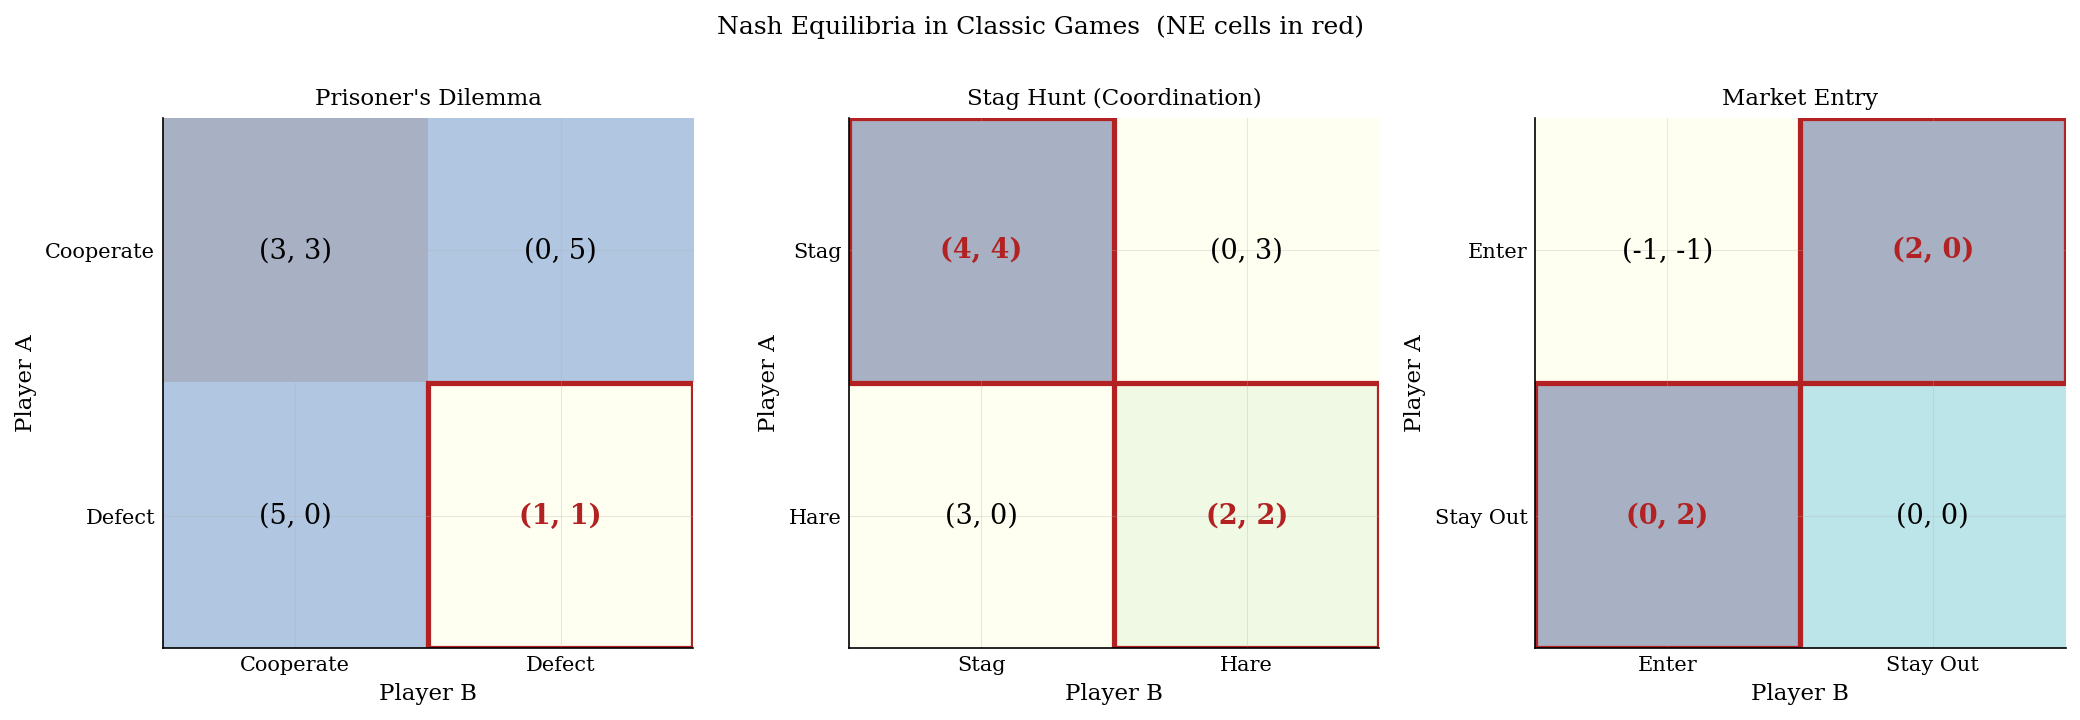

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, game in zip(axes, games):
    A, B = game['A'], game['B']
    ne = find_pure_nash(A, B)
    strats = game['strategies']
    m, n = A.shape

    bg = (A + B).astype(float)
    ax.imshow(bg, cmap='YlGnBu', alpha=0.35, aspect='equal',
              extent=(-0.5, n - 0.5, m - 0.5, -0.5))

    for i in range(m):
        for j in range(n):
            label = f"({A[i, j]}, {B[i, j]})"
            is_ne = (i, j) in ne
            ax.text(j, i, label, ha='center', va='center', fontsize=13,
                    fontweight='bold' if is_ne else 'normal',
                    color='#B22222' if is_ne else 'black')
            if is_ne:
                rect = Rectangle((j - 0.5, i - 0.5), 1, 1, linewidth=2.5,
                                 edgecolor='#B22222', facecolor='none')
                ax.add_patch(rect)

    ax.set_xticks(range(n))
    ax.set_xticklabels(strats, fontsize=10)
    ax.set_yticks(range(m))
    ax.set_yticklabels(strats, fontsize=10)
    ax.set_xlabel('Player B')
    ax.set_ylabel('Player A')
    ax.set_title(game['title'], fontsize=11)
    ax.tick_params(length=0)

fig.suptitle('Nash Equilibria in Classic Games  (NE cells in red)',
             fontsize=12, y=1.03)
fig.tight_layout()
save_fig(fig, '05_game_theory', 'nash_equilibria_heatmaps')
plt.show()

## Section 2 — Auction Theory

### Sealed-Bid Auction Formats

| Format | Rule | Optimal bid |
|---|---|---|
| **First-price** | Highest bidder wins, pays own bid | Shade below value: $b^*(v) = v \cdot \tfrac{n-1}{n}$ |
| **Second-price (Vickrey)** | Highest bidder wins, pays second-highest bid | Bid truthfully: $b^*(v) = v$ |

where $v$ is the bidder's private valuation drawn from $U[0,1]$ and $n$ is the number of bidders.

### Optimal Bid Shading (First-Price)

With $n$ bidders and values i.i.d. $\sim U[0,1]$, a bidder with value $v$ maximises expected payoff:

$$\max_b \; (v - b) \cdot \Pr(\text{win} \mid b) = (v - b) \cdot b^{n-1}$$

Taking the first-order condition and solving:

$$b^*(v) = v \cdot \frac{n-1}{n}$$

Intuition: with more competitors you shade less because you must bid higher to win.

### Revenue Equivalence Theorem

Under i.i.d. private values and risk-neutral bidders, the **expected revenue** is identical across all standard auction formats:

$$E[\text{revenue}] = E\!\left[\text{max}^{(2)}\right] = \frac{n-1}{n+1}$$

where $\text{max}^{(2)}$ is the second-highest order statistic from $n$ draws of $U[0,1]$.

In [5]:
def simulate_auction(
    n_bidders: int,
    n_auctions: int,
    auction_type: str,
    rng: np.random.Generator,
) -> dict[str, np.ndarray]:
    """Simulate sealed-bid auctions with optimal bidding strategies.

    Parameters
    ----------
    n_bidders : int
        Number of bidders in each auction.
    n_auctions : int
        Number of independent auctions to simulate.
    auction_type : str
        ``'first_price'`` or ``'second_price'``.
    rng : np.random.Generator
        Random number generator for reproducibility.

    Returns
    -------
    dict with keys
        ``'revenues'``         — price paid per auction,
        ``'winner_values'``    — true value of the auction winner,
        ``'winner_bids'``      — bid submitted by the winner,
        ``'winner_surpluses'`` — winner's value minus price paid.

    Notes
    -----
    Bidders draw private values from U[0, 1].
    First-price: optimal bid = v * (n-1)/n  (bid shading).
    Second-price: optimal bid = v  (truthful, dominant strategy).
    """
    values = rng.uniform(0.0, 1.0, size=(n_auctions, n_bidders))

    if auction_type == 'first_price':
        bids = values * (n_bidders - 1) / n_bidders
    elif auction_type == 'second_price':
        bids = values.copy()
    else:
        raise ValueError(f"Unknown auction_type: {auction_type!r}")

    winner_idx = np.argmax(bids, axis=1)
    rows = np.arange(n_auctions)
    winner_values = values[rows, winner_idx]
    winner_bids = bids[rows, winner_idx]

    if auction_type == 'first_price':
        revenues = winner_bids.copy()
    else:
        sorted_bids = np.sort(bids, axis=1)
        revenues = sorted_bids[:, -2]

    return {
        'revenues': revenues,
        'winner_values': winner_values,
        'winner_bids': winner_bids,
        'winner_surpluses': winner_values - revenues,
    }

In [6]:
rng = np.random.default_rng(42)
n_sims = 10_000
n_bidders = 5
v = 0.8

strategies: dict[str, float] = {
    'Truthful (b = v)':           v,
    'Optimal shading (b = 0.64)': v * (n_bidders - 1) / n_bidders,
    'Under-shading (b = 0.72)':   v * 0.9,
    'Over-shading (b = 0.48)':    v * 0.6,
}

opponent_values = rng.uniform(0.0, 1.0, size=(n_sims, n_bidders - 1))
opponent_bids = opponent_values * (n_bidders - 1) / n_bidders

print(f"First-price auction  |  {n_bidders} bidders  |  your value v = {v}")
print(f"Opponents bid optimally: b = v * {(n_bidders - 1) / n_bidders:.2f}")
print()
print(f"{'Strategy':<30s}  {'Bid':>5s}  {'Win %':>6s}  {'E[payoff]':>10s}")
print('-' * 58)

best_name, best_payoff = '', -np.inf
for name, bid in strategies.items():
    wins = bid > np.max(opponent_bids, axis=1)
    payoffs = np.where(wins, v - bid, 0.0)
    expected = float(np.mean(payoffs))
    win_pct = float(np.mean(wins)) * 100
    print(f"{name:<30s}  {bid:5.2f}  {win_pct:5.1f}%  {expected:10.4f}")
    if expected > best_payoff:
        best_payoff = expected
        best_name = name

print(f"\nBest strategy: {best_name}  (E[payoff] = {best_payoff:.4f})")

First-price auction  |  5 bidders  |  your value v = 0.8
Opponents bid optimally: b = v * 0.80

Strategy                          Bid   Win %   E[payoff]
----------------------------------------------------------
Truthful (b = v)                 0.80  100.0%      0.0000
Optimal shading (b = 0.64)       0.64   40.9%      0.0655
Under-shading (b = 0.72)         0.72   65.6%      0.0525
Over-shading (b = 0.48)          0.48   12.4%      0.0397

Best strategy: Optimal shading (b = 0.64)  (E[payoff] = 0.0655)


Saved → plots/05_game_theory/revenue_equivalence.[pdf|png]


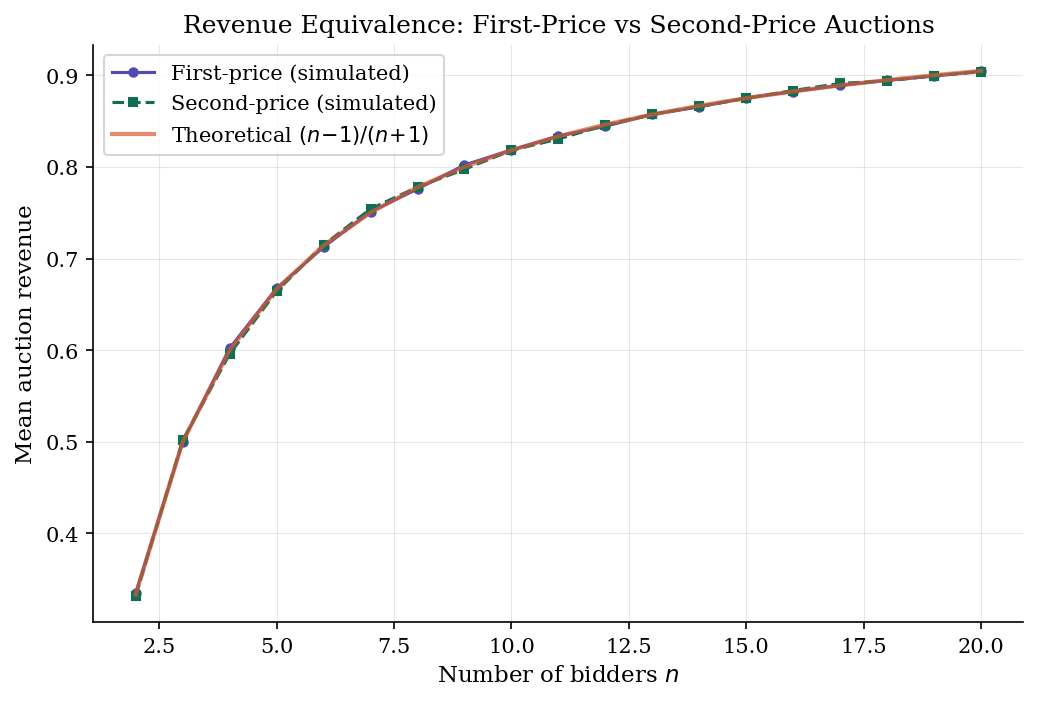

In [7]:
n_auctions = 5_000
bidder_range = np.arange(2, 21)

mean_rev_fp = np.empty(len(bidder_range))
mean_rev_sp = np.empty(len(bidder_range))

for idx, n in enumerate(bidder_range):
    seed_rng = np.random.default_rng(idx)
    fp = simulate_auction(n, n_auctions, 'first_price', seed_rng)
    seed_rng = np.random.default_rng(idx + 1000)
    sp = simulate_auction(n, n_auctions, 'second_price', seed_rng)
    mean_rev_fp[idx] = np.mean(fp['revenues'])
    mean_rev_sp[idx] = np.mean(sp['revenues'])

theoretical = (bidder_range - 1) / (bidder_range + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(bidder_range, mean_rev_fp, 'o-', color=COLORS[0], lw=1.5, ms=4,
        label='First-price (simulated)')
ax.plot(bidder_range, mean_rev_sp, 's--', color=COLORS[1], lw=1.5, ms=4,
        label='Second-price (simulated)')
ax.plot(bidder_range, theoretical, '-', color=COLORS[2], lw=2, alpha=0.7,
        label=r'Theoretical $(n\!-\!1)/(n\!+\!1)$')
ax.set_xlabel(r'Number of bidders $n$')
ax.set_ylabel('Mean auction revenue')
ax.set_title('Revenue Equivalence: First-Price vs Second-Price Auctions')
ax.legend()
save_fig(fig, '05_game_theory', 'revenue_equivalence')
plt.show()

## Section 3 — Application to Prosperity

### 1. Order-Book Competition as a Simultaneous Game

Multiple bots choose spread widths simultaneously each tick. A narrower spread captures more volume but exposes the bot to greater **adverse selection** — executing against informed flow that knows the true price has moved.

Frame this as a symmetric game:
- **Players:** $N$ market-making bots.
- **Strategies:** spread width $\delta \in [\delta_{\min}, \delta_{\max}]$.
- **Payoff:** $\pi(\delta_i, \delta_{-i}) = \text{fill\_rate}(\delta_i, \delta_{-i}) \times (\delta_i - \text{adverse\_selection\_cost})$.

In the symmetric Nash equilibrium all bots set the same spread $\delta^*$. As $N$ increases, competition drives $\delta^*$ toward the adverse-selection cost — the zero-profit condition of a competitive market. If all bots use Avellaneda–Stoikov with similar parameters, their reservation prices converge and the equilibrium spread is roughly $2\delta^*_{\text{AS}}$.

**Implication:** count the active competitors. With 5+ aggressive market makers, per-bot profit is thin; consider switching to a directional or stat-arb strategy.

### 2. Pricing Rounds as Auctions

In Prosperity rounds where bots submit prices (e.g., for exotic products or basket trades), the mechanism is functionally a **sealed-bid auction**:

- **Second-price logic (Vickrey):** if the winner pays the second-best price, the dominant strategy is to bid your true estimated value. No game-theoretic sophistication needed — just get the valuation right.
- **First-price logic:** if you pay your own submitted price, optimal shading applies. With $n$ competitors whose values are roughly $U[v_{\text{low}}, v_{\text{high}}]$, shade by a factor of $(n-1)/n$.
- **Key insight:** determine the auction mechanism *first*, then apply the corresponding optimal strategy. Misidentifying the mechanism (e.g., bidding truthfully in a first-price setting) leaves money on the table.

### 3. Multi-Round Learning as a Repeated Game

Prosperity runs for many ticks across multiple rounds. This transforms a one-shot game into a **repeated game**, fundamentally changing equilibrium behaviour:

- **Folk theorem:** any payoff profile that Pareto-dominates the one-shot NE can be sustained as an equilibrium of the infinitely repeated game, provided players are sufficiently patient ($\delta$ close to 1).
- **Tit-for-tat:** if a competitor consistently undercuts your spreads, respond by widening to avoid a race to the bottom. If they maintain cooperative spreads, reciprocate.
- **Grim trigger:** defect once $\to$ punish forever. This is extreme but effective against bots that test boundaries.
- **Practical approach:** track each competitor's spread history over the last $k$ ticks. Compute a moving average of their aggressiveness. Adjust your own spread proportionally.

### 4. Information Asymmetry and Signalling

Bots that **trade aggressively** (large market orders, taking liquidity) signal that they possess private information about the fair value. Rational market makers should:

1. **Detect informed flow:** track order-flow imbalance over short windows. A sustained buy imbalance suggests an informed buyer.
2. **Update beliefs (Bayesian):** $P(\text{fair value shifted} \mid \text{buy imbalance}) \propto P(\text{imbalance} \mid \text{shift}) \cdot P(\text{shift})$.
3. **Respond:** widen the spread when informed flow is detected (increase $\gamma$ in the AS model). Narrow it when flow is balanced (uninformed, inventory-driven).

This is the **adverse selection** channel that Glosten & Milgrom (1985) formalised: the bid–ask spread exists *precisely* to compensate the market maker for trading against better-informed counterparties.

## Prosperity 4 Takeaways

- **Model competitors as rational agents:** assume other bots use known strategy classes (mostly AS-like market makers) and best-respond accordingly. Don't assume competitors are naïve — but do exploit predictable patterns when you identify them.

- **In pricing rounds, apply Vickrey auction logic:** if the mechanism is second-price, bid your true estimated value. If first-price, shade by $(n-1)/n$ where $n$ is the number of competitors. Determine the mechanism before choosing your strategy.

- **Count active competitors:** more competition $\to$ tighter equilibrium spreads $\to$ lower per-bot profit. Monitor the number of active bots and adjust your strategy class (market-making vs directional vs stat-arb) based on the competitive landscape.

- **Exploit predictable bots:** if you identify an opponent's strategy (e.g., always quoting a fixed spread, or following a simple mean-reversion rule), compute the exact best response rather than playing a generic strategy. Information about opponents is the most valuable edge.

- **Track opponent behaviour across rounds:** patterns emerge over time, and adaptive strategies (tit-for-tat, Bayesian updating on opponent type) outperform static ones. Build a model of each competitor's behaviour and update it every round.